# Advertising Campaign Performance Analysis

This project analyzes a synthetic advertising campaign dataset using Python, Pandas, and Matplotlib in Google Colab. The dataset includes campaign performance across Google Ads, Meta Ads, and TikTok Ads, with metrics such as impressions, clicks, ad spend, conversions, revenue, ROAS, CPA, CTR, and CPC.

The goal of this project was to compare campaign performance by platform, campaign type, industry, and country. The analysis focused on identifying which areas had the strongest return on ad spend, the lowest costs, and the best overall advertising efficiency.

Performance comparison tables were sorted from highest to lowest average ROAS to highlight the strongest-performing categories first.


## Metrics Used

* **ROAS**: Return on Ad Spend. Measures how much revenue was generated for each dollar spent on ads.
* **CPA**: Cost Per Acquisition. Measures how much it cost to get one conversion.
* **CTR**: Click-Through Rate. Measures how often people clicked after seeing an ad.
* **CPC**: Cost Per Click. Measures how much each click cost.
* **Ad Spend**: The amount spent on advertising.
* **Revenue**: The amount generated from the campaigns.
* **Conversions**: Completed campaign actions, such as purchases, sign-ups, or leads.




## Data Preview

The dataset was downloaded into a CSV file was put into Google Colab using Pandas and stored it as a dataframe named `df`.  `df.head()` was used to preview the first five rows of the dataset and to confirm that the file loaded correctly. This preview showed the main columns used in the analysis, including platform, campaign type, industry, country, impressions, clicks, ad spend, conversions, revenue, CPA, CTR, CPC, and ROAS.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("global_ads_performance_dataset.csv")
df.head()

,date,platform,campaign_type,industry,country,impressions,clicks,CTR,CPC,ad_spend,conversions,CPA,revenue,ROAS
0,2024-01-21,Google Ads,Search,Fintech,UAE,59886,2113,0.0353,1.26,2662.38,159,16.74,4803.43,1.80
1,2024-01-22,TikTok Ads,Search,EdTech,UK,135608,5220,0.0385,1.18,6159.60,411,14.99,64126.68,10.41
2,2024-06-15,TikTok Ads,Video,Healthcare,USA,92313,5991,0.0649,0.85,5092.35,267,19.07,10489.07,2.06
3,2024-01-02,TikTok Ads,Shopping,SaaS,Germany,83953,5935,0.0707,1.32,7834.20,296,26.47,50505.07,6.45
4,2024-02-22,TikTok Ads,Search,Healthcare,UK,91807,4489,0.0489,1.93,8663.77,107,80.97,3369.53,0.39


## Data Inspection

 `df.info()` was used to check the dataset structure, including the number of rows, columns, data types, and missing values. The dataset contains 1,800 rows and 14 columns, with no missing values.  `df.describe()` was also used to review summary statistics for numeric columns such as impressions, clicks, CTR, CPC, ad spend, conversions, CPA, revenue, and ROAS. Each numeric column showed the average, minimum, maximum, and percentile ranges of the values, which helped give an overview of how the campaign metrics were distributed.

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1800 non-null   object 
 1   platform       1800 non-null   object 
 2   campaign_type  1800 non-null   object 
 3   industry       1800 non-null   object 
 4   country        1800 non-null   object 
 5   impressions    1800 non-null   int64  
 6   clicks         1800 non-null   int64  
 7   CTR            1800 non-null   float64
 8   CPC            1800 non-null   float64
 9   ad_spend       1800 non-null   float64
 10  conversions    1800 non-null   int64  
 11  CPA            1800 non-null   float64
 12  revenue        1800 non-null   float64
 13  ROAS           1800 non-null   float64
dtypes: float64(6), int64(3), object(5)
memory usage: 197.0+ KB


,impressions,clicks,CTR,CPC,ad_spend,conversions,CPA,revenue,ROAS
count,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,102919.018889,3962.675556,0.038427,1.572756,6171.527272,181.562222,46.608961,30101.850450,6.450367
std,55740.900690,2941.858037,0.017082,0.800872,5776.996958,171.424239,41.185556,34560.032941,6.590986
min,5059.000000,91.000000,0.008900,0.280000,58.000000,2.000000,4.800000,142.690000,0.130000
25%,54948.000000,1678.000000,0.025400,0.950000,1966.587500,59.000000,20.202500,7275.757500,2.170000
50%,103653.000000,3318.000000,0.035550,1.460000,4393.860000,130.000000,33.375000,18362.965000,4.295000
75%,150470.250000,5628.000000,0.049800,2.050000,8455.830000,252.250000,56.812500,38963.385000,8.212500
max,199650.000000,16660.000000,0.095600,3.950000,38453.320000,1151.000000,335.860000,295028.260000,49.000000


## Platform Performance

The dataset was grouped by advertising platform to compare Google Ads, Meta Ads, and TikTok Ads. For each platform, calculations were done on total ad spend, total revenue, total conversions, average ROAS, average CPA, average CTR, and average CPC.


In [ ]:
platform_performance = df.groupby("platform").agg({
    "ad_spend": "sum",
    "revenue": "sum",
    "conversions": "sum",
    "ROAS": "mean",
    "CPA": "mean",
    "CTR": "mean",
    "CPC": "mean"
}).sort_values("ROAS", ascending=False)

platform_performance

,ad_spend,revenue,conversions,ROAS,CPA,CTR,CPC
platform,,,,,,,
TikTok Ads,2653418.51,20223540.07,122452,9.538600,29.196711,0.054963,1.009978
Meta Ads,2106061.67,11926045.79,73262,6.915730,39.096921,0.024983,1.316095
Google Ads,6349268.91,22033744.95,131098,4.113028,64.064653,0.039856,2.149069


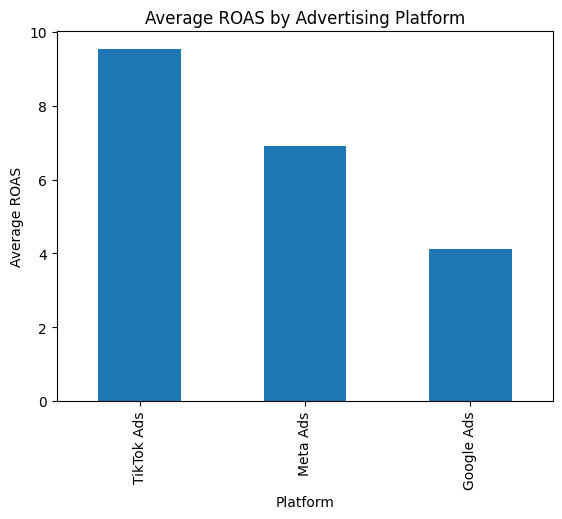

In [ ]:
platform_roas = df.groupby("platform")["ROAS"].mean().sort_values(ascending=False)

platform_roas.plot(kind="bar")
plt.title("Average ROAS by Advertising Platform")
plt.xlabel("Platform")
plt.ylabel("Average ROAS")
plt.show()

### Platform ROAS Insight

TikTok Ads had the highest average ROAS, meaning it generated the strongest return for each dollar spent on ads. Meta Ads was second, while Google Ads had the lowest average ROAS. This suggests that TikTok Ads was the most efficient platform overall.

Although Google Ads had high total revenue and conversions in the table above, its lower average ROAS shows that it required more ad spend to generate those results compared with TikTok Ads.

## Campaign Type Performance
The dataset was grouped by campaign type to compare Search, Display, Video, and Shopping campaigns. For each campaign type, I calculated total ad spend, total revenue, total conversions, average ROAS, average CPA, average CTR, and average CPC.

This helps identify which campaign type performed best overall and which type was most efficient at generating returns from ad spend.

In [ ]:
campaign_performance=df.groupby("campaign_type").agg({
    "ad_spend":"sum",
    "revenue":"sum",
    "conversions":"sum",
    "ROAS":"mean",
    "CPA":"mean",
    "CTR":"mean",
    "CPC":"mean"}).sort_values("ROAS", ascending=False)
campaign_performance

,ad_spend,revenue,conversions,ROAS,CPA,CTR,CPC
campaign_type,,,,,,,
Search,2868006.85,15218470.85,90641,7.000273,44.299099,0.039426,1.530566
Display,2644735.12,12798903.17,76869,6.448667,45.849548,0.038091,1.615238
Video,2796458.48,13341261.19,79228,6.340000,48.361996,0.037630,1.578509
Shopping,2799548.64,12824695.60,80074,5.977740,47.999060,0.038489,1.571991


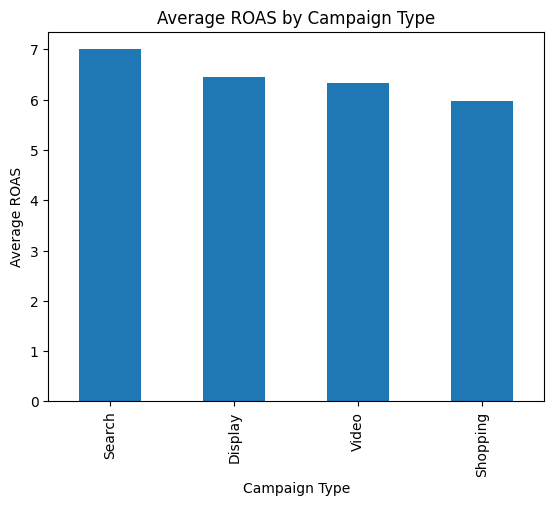

In [ ]:
campaign_roas=df.groupby("campaign_type")["ROAS"].mean().sort_values(ascending=False)

campaign_roas.plot(kind="bar")
plt.title("Average ROAS by Campaign Type")
plt.xlabel("Campaign Type")
plt.ylabel("Average ROAS")
plt.show()

### Campaign Type ROAS Insight

Search campaigns had the highest average ROAS by campaign type, followed by Display, Video, and Shopping. This suggests that Search campaigns generated the strongest return compared with the amount spent on advertising. In other words, Search was the most efficient campaign type based on average ROAS in this dataset.



## Industry Performance

Ads were grouped by industry to compare which business categories performed best overall. The ads still came from Google Ads, Meta Ads, and TikTok Ads, but this section focuses on the industry each ad was associated with rather than the platform itself.

For each industry, calculations were done for total ad spend, total revenue, total conversions, average ROAS, average CPA, average CTR, and average CPC.

In [ ]:
industry_performance=df.groupby("industry").agg({
    "ad_spend":"sum",
    "revenue":"sum",
    "conversions":"sum",
    "ROAS":"mean",
    "CPA":"mean",
    "CTR":"mean",
    "CPC":"mean"}).sort_values("ROAS", ascending=False)
industry_performance

,ad_spend,revenue,conversions,ROAS,CPA,CTR,CPC
industry,,,,,,,
EdTech,2296978.52,11549934.43,67257,6.828952,48.038737,0.037718,1.554140
SaaS,2357561.84,11891991.42,71261,6.647973,45.772919,0.039800,1.545135
Healthcare,2258683.92,10930814.04,65687,6.587989,47.559368,0.038109,1.620402
E-commerce,1923987.08,9637279.69,57486,6.133524,45.043811,0.037251,1.558711
Fintech,2271537.73,10173311.23,65121,6.031357,46.589446,0.039194,1.587895


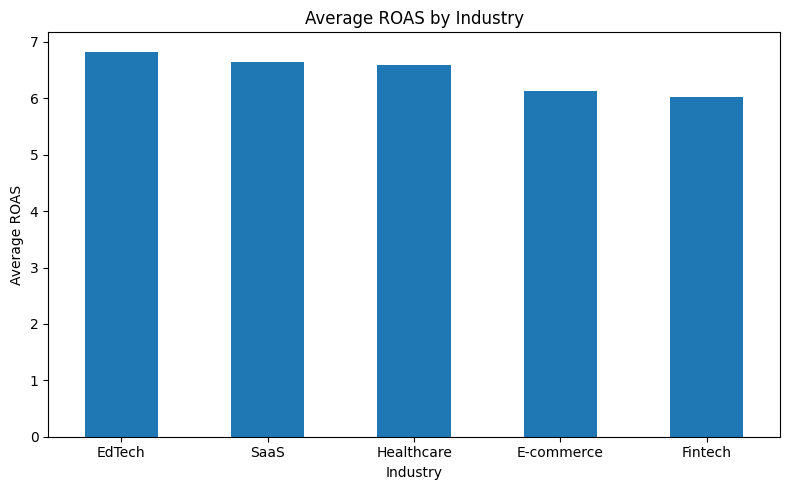

In [ ]:
industry_roas = df.groupby("industry")["ROAS"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
industry_roas.plot(kind="bar")

plt.title("Average ROAS by Industry")
plt.xlabel("Industry")
plt.ylabel("Average ROAS")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Industry ROAS Insight

EdTech had the highest average ROAS, followed by SaaS and Healthcare. This suggests that EdTech campaigns generated the strongest return for each dollar spent on ads. Although SaaS had slightly higher total revenue and conversions, EdTech was the most efficient industry in terms of return on ad spend.

## Country Performance

The dataset was grouped by country to compare advertising performance across Australia, Canada, Germany, India, UAE, UK, and USA. For each country, calculations were made to the total ad spend, total revenue, total conversions, average ROAS, average CPA, average CTR, and average CPC.

In [ ]:
country_performance = df.groupby("country").agg({
    "ad_spend": "sum",
    "revenue": "sum",
    "conversions": "sum",
    "ROAS": "mean",
    "CPA": "mean",
    "CTR": "mean",
    "CPC": "mean"
}).sort_values("ROAS", ascending=False)

country_performance

,ad_spend,revenue,conversions,ROAS,CPA,CTR,CPC
country,,,,,,,
UAE,1614677.33,7939594.41,48345,6.962054,45.294845,0.039472,1.559419
Germany,1551062.17,7694838.61,44768,6.709647,45.617098,0.038913,1.546039
Australia,1586264.94,7921847.84,45869,6.674526,48.761034,0.038675,1.634224
India,1438741.76,7909606.26,46767,6.649732,45.250038,0.038701,1.517280
Canada,1643262.54,7867323.12,46243,6.258015,50.315916,0.037715,1.605267
UK,1547153.48,7659544.29,46842,6.145038,45.805451,0.036856,1.547331
USA,1727586.87,7190576.28,47978,5.809173,45.443083,0.038734,1.605526


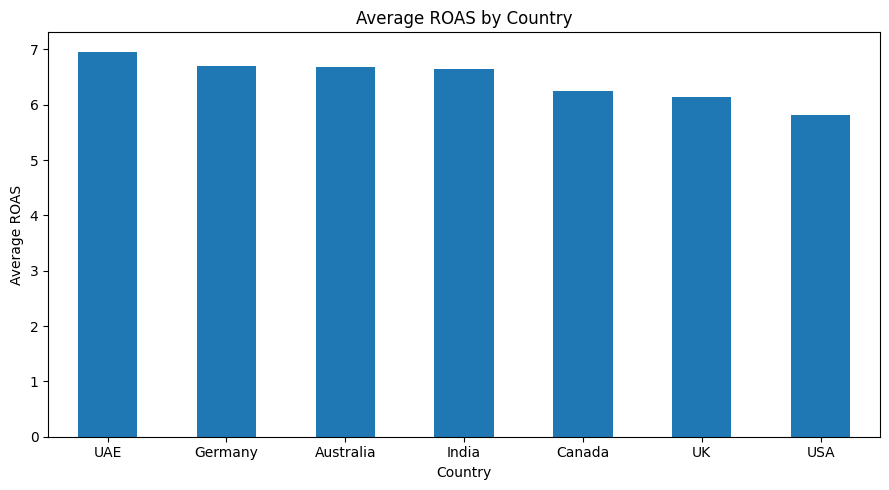

In [ ]:
country_roas = df.groupby("country")["ROAS"].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
country_roas.plot(kind="bar")

plt.title("Average ROAS by Country")
plt.xlabel("Country")
plt.ylabel("Average ROAS")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Country ROAS Insight

The country ROAS chart shows that the UAE had the highest average ROAS, followed by Germany, Australia, and India. This suggests that these countries generated stronger returns from ad spend. The USA had the lowest average ROAS, even though it had high conversions, which suggests it was less efficient compared with other countries.

## Ad Spend vs Revenue

A scatter plot to compare ad spend and revenue across individual campaigns. Each point in the chart represents one campaign. This helps show whether campaigns with higher ad spend also tended to generate higher revenue.

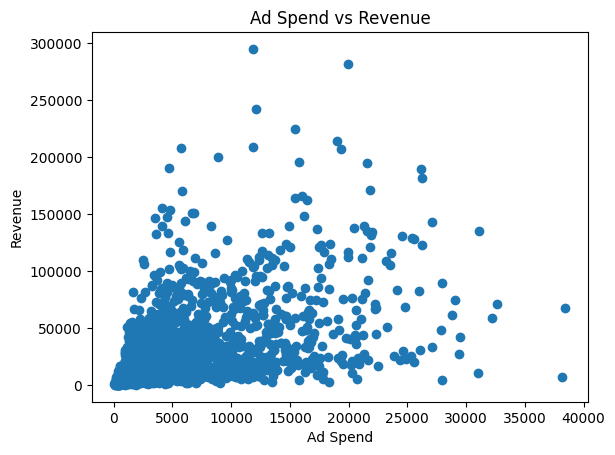

In [ ]:
plt.scatter(df["ad_spend"], df["revenue"])
plt.title("Ad Spend vs Revenue")
plt.xlabel("Ad Spend")
plt.ylabel("Revenue")
plt.show()

### Ad Spend vs Revenue Insight

The scatter plot shows a general positive relationship between ad spend and revenue, meaning campaigns with higher ad spend often generated higher revenue. However, most of the data points are concentrated in the lower ad spend and lower revenue range, showing that many campaigns operated at smaller budgets and produced more moderate revenue. The wider spread of points at higher ad spend levels shows that spending more did not always guarantee higher revenue. This supports the need to compare efficiency metrics like ROAS and CPA, not just total spend.

## CPA by Platform

I compared the average CPA for each advertising platform to understand which platform generated conversions at the lowest cost. A lower CPA is better because it means each conversion costs less.

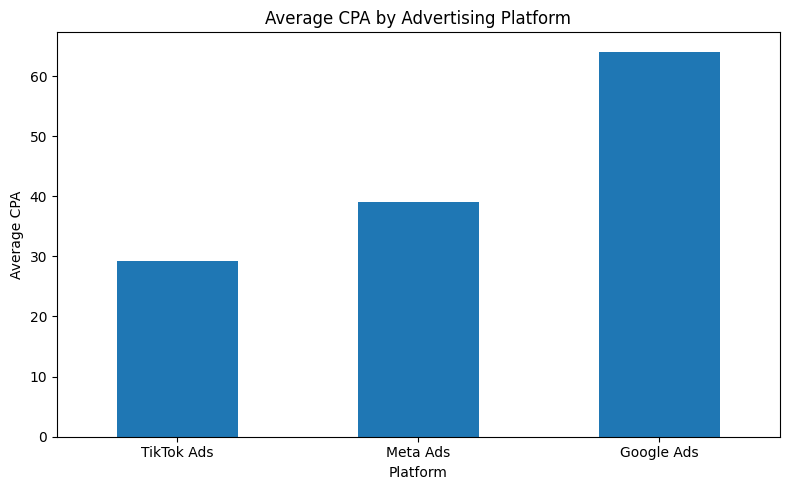

In [ ]:
platform_cpa = df.groupby("platform")["CPA"].mean().sort_values(ascending=True)

plt.figure(figsize=(8, 5))
platform_cpa.plot(kind="bar")

plt.title("Average CPA by Advertising Platform")
plt.xlabel("Platform")
plt.ylabel("Average CPA")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### CPA Platform Insight

TikTok Ads had the lowest average CPA, making it the most cost-efficient platform for acquiring conversions. Meta Ads had the second-lowest average CPA, while Google Ads had the highest average CPA. This suggests that Google Ads was less cost-efficient because it cost more to generate each conversion.

## Platform and Campaign Type Performance

For this section, data was grouped by both advertising platform and campaign type. This allowed for comparing more specific combinations, such as TikTok Search, TikTok Display, Meta Search, and Google Shopping.

This section helps show whether certain campaign types performed better on specific platforms. For each platform and campaign type combination, comparisons were made to total ad spend, total revenue, total conversions, average ROAS, average CPA, average CTR, and average CPC.


In [ ]:
combo_performance = df.groupby(["platform", "campaign_type"]).agg({
    "ad_spend": "sum",
    "revenue": "sum",
    "conversions": "sum",
    "ROAS": "mean",
    "CPA": "mean",
    "CTR": "mean",
    "CPC": "mean"
}).sort_values("ROAS", ascending=False)

combo_performance

ad_spend     revenue  conversions       ROAS  \
platform   campaign_type                                                   
TikTok Ads Search          717501.95  5824810.16        35475  10.519280   
           Display         615956.86  4935068.73        28934  10.036931   
           Video           596829.64  4509110.15        27515   9.572286   
           Shopping        723130.06  4954551.03        30528   8.055798   
Meta Ads   Display         547625.69  3188913.09        18634   7.270138   
           Search          520979.29  3007006.05        18339   6.902312   
           Shopping        501876.55  2778261.94        19127   6.767500   
           Video           535580.14  2951864.71        17162   6.761030   
Google Ads Search         1629525.61  6386654.64        36827   4.790885   
           Video          1664048.70  5880286.33        34551   4.141828   
           Shopping       1574542.03  5091882.63        30419   3.753631   
           Display        1481152.57  4674921.35        29301   3.681264   

                                CPA       CTR       CPC  
platform   campaign_type                                 
TikTok Ads Search         27.314800  0.055977  0.986640  
           Display        26.714950  0.054852  1.046238  
           Video          29.630000  0.053755  0.970952  
           Shopping       32.897563  0.055056  1.038151  
Meta Ads   Display        35.860483  0.024696  1.339448  
           Search         41.451500  0.025117  1.350625  
           Shopping       38.074562  0.024778  1.252750  
           Video          40.649212  0.025303  1.323515  
Google Ads Search         57.729583  0.040574  2.034635  
           Video          65.778495  0.039463  2.147688  
           Shopping       68.147857  0.039812  2.254167  
           Display        65.280632  0.039524  2.175345

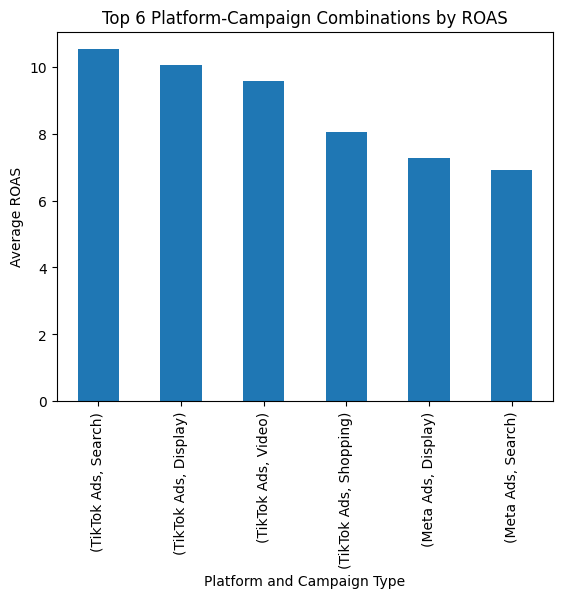

In [ ]:
top_combo_roas = combo_performance["ROAS"].head(6)

top_combo_roas.plot(kind="bar")
plt.title("Top 6 Platform-Campaign Combinations by ROAS")
plt.xlabel("Platform and Campaign Type")
plt.ylabel("Average ROAS")
plt.show()

### Platform and Campaign Type ROAS Insight

TikTok Ads dominated the top-performing platform and campaign type combinations. TikTok Search had the highest average ROAS, followed by TikTok Display and TikTok Video. This suggests that TikTok campaigns were the strongest overall, especially when paired with Search and Display campaign types.

Meta Display and Meta Search also appeared in the top six, showing that Meta performed well for some campaign types. Google Ads did not appear in the top six combinations, which suggests it was less efficient by average ROAS compared with TikTok and Meta in this dataset.

## Final Summary and Recommendations

Overall, TikTok Ads was the strongest platform for efficiency, with the highest average ROAS and lowest average CPA. Search campaigns also performed strongly, especially when paired with TikTok Ads. EdTech had the highest average ROAS by industry, while the UAE had the highest average ROAS by country.

Based on these results, future advertising strategy should prioritize TikTok Ads, especially TikTok Search and TikTok Display campaigns, because they generated the strongest return on ad spend. Google Ads should also be reviewed for efficiency because it generated high total revenue and conversions, but had lower efficiency compared with TikTok Ads and Meta Ads.
